<a href="https://colab.research.google.com/github/ompandey0211/BlackFriday-Sales-Prediction/blob/main/BLaCK_FRiDAY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [293]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [294]:
from google.colab import files
uploaded = files.upload()

Saving BlackFriday.csv to BlackFriday.csv


In [295]:
df = pd.read_csv("BlackFriday.csv")
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [296]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 537577 entries, 0 to 537576
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     537577 non-null  int64  
 1   Product_ID                  537577 non-null  object 
 2   Gender                      537577 non-null  object 
 3   Age                         537577 non-null  object 
 4   Occupation                  537577 non-null  int64  
 5   City_Category               537577 non-null  object 
 6   Stay_In_Current_City_Years  537577 non-null  object 
 7   Marital_Status              537577 non-null  int64  
 8   Product_Category_1          537577 non-null  int64  
 9   Product_Category_2          370591 non-null  float64
 10  Product_Category_3          164278 non-null  float64
 11  Purchase                    537577 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 49.2+ MB


In [297]:
df.isna().sum()


,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category_1,0
Product_Category_2,166986


In [298]:
del df['Product_Category_2']
del df['Product_Category_3']

In [299]:
df


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969
...,...,...,...,...,...,...,...,...,...,...
537572,1004737,P00193542,M,36-45,16,C,1,0,1,11664
537573,1004737,P00111142,M,36-45,16,C,1,0,1,19196
537574,1004737,P00345942,M,36-45,16,C,1,0,8,8043
537575,1004737,P00285842,M,36-45,16,C,1,0,5,7172


In [300]:
print(df.columns.tolist())

['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category', 'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1', 'Purchase']


In [301]:
df['Product_ID'].unique()

df['Age'].unique()

df['Occupation'].unique()

df['City_Category'].unique()

df['Stay_In_Current_City_Years'].unique()

df['Marital_Status'].unique()

df['Product_Category_1'].unique()

df['Purchase'].unique()

array([ 8370, 15200,  1422, ..., 14539, 11120, 18426])

<Axes: ylabel='Ratio'>

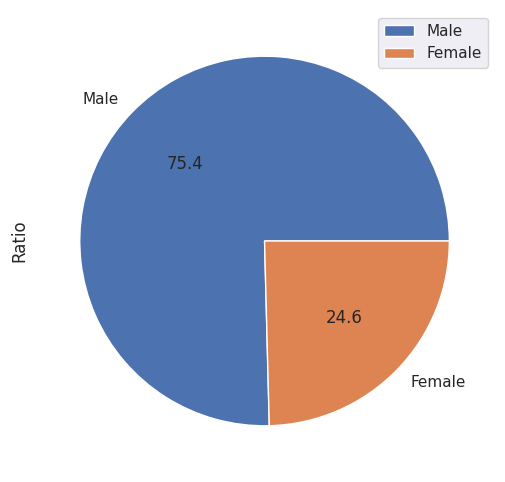

In [302]:
data = pd.DataFrame({'Ratio' : [len(df[df['Gender'] == 'M']), len(df[df['Gender'] == 'F'])]}, index = ['Male' , 'Female'])
data.plot.pie(y ='Ratio', figsize = (6,6), autopct = "%.1f")

In [303]:
df.head()

df.shape

df.info()

df.describe()

df.columns

df.isnull().sum()

df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 537577 entries, 0 to 537576
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     537577 non-null  int64 
 1   Product_ID                  537577 non-null  object
 2   Gender                      537577 non-null  object
 3   Age                         537577 non-null  object
 4   Occupation                  537577 non-null  int64 
 5   City_Category               537577 non-null  object
 6   Stay_In_Current_City_Years  537577 non-null  object
 7   Marital_Status              537577 non-null  int64 
 8   Product_Category_1          537577 non-null  int64 
 9   Purchase                    537577 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 41.0+ MB


np.int64(0)

In [304]:
df.drop("User_ID",axis=1,inplace=True)

In [305]:
df.drop("Product_ID",axis=1,inplace=True)

In [306]:
print(df.columns)

Index(['Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1',
       'Purchase'],
      dtype='object')


In [307]:
print(df.columns.tolist())

['Gender', 'Age', 'Occupation', 'City_Category', 'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1', 'Purchase']


In [308]:
df["Gender"]=df["Gender"].map({
    "M":1,
    "F":0
})

In [309]:
df=pd.get_dummies(df,
                  columns=["City_Category"],
                  drop_first=True)

In [310]:
age_map={
    "0-17":0,
    "18-25":1,
    "26-35":2,
    "36-45":3,
    "46-50":4,
    "51-55":5,
    "55+":6
}

df["Age"]=df["Age"].map(age_map)

In [311]:
df["Stay_In_Current_City_Years"]=df["Stay_In_Current_City_Years"].replace("4+",4)

df["Stay_In_Current_City_Years"]=df["Stay_In_Current_City_Years"].astype(int)

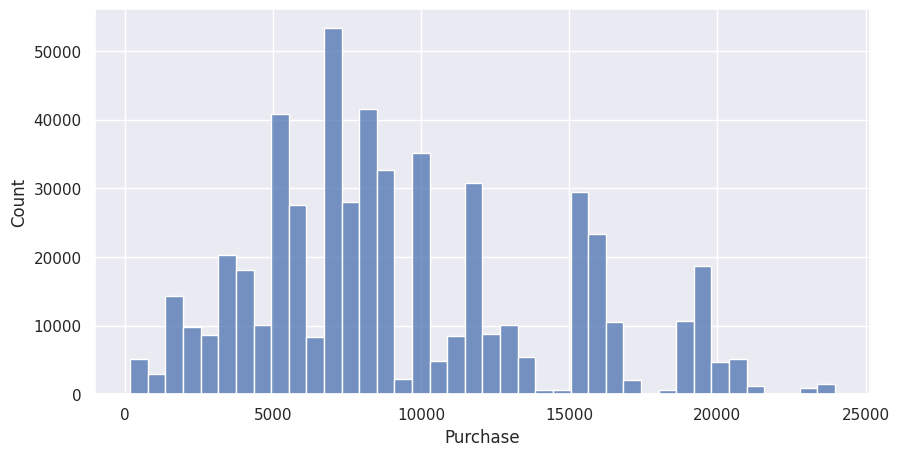

In [312]:
plt.figure(figsize=(10,5))
sns.histplot(df["Purchase"],bins=40)
plt.show()

<Axes: xlabel='Gender', ylabel='Purchase'>

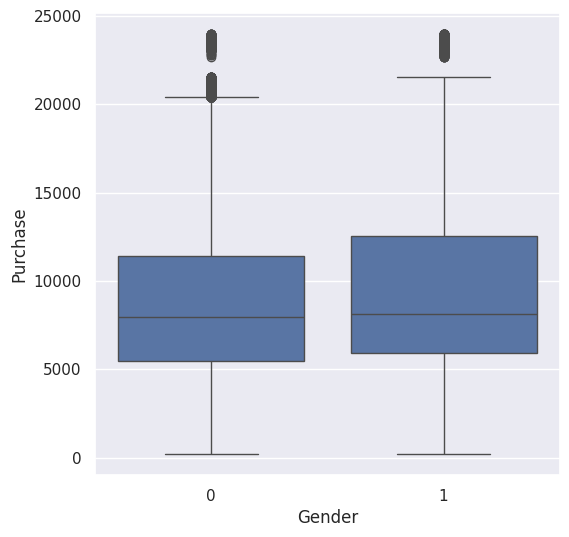

In [313]:
sns.boxplot(x="Gender",y="Purchase",data=df)

<Axes: xlabel='Age', ylabel='Purchase'>

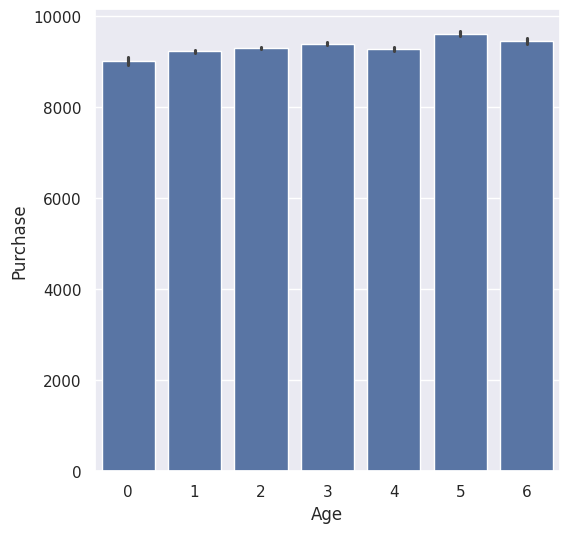

In [314]:
sns.barplot(x="Age",y="Purchase",data=df)

<Axes: xlabel='City_Category_B', ylabel='Purchase'>

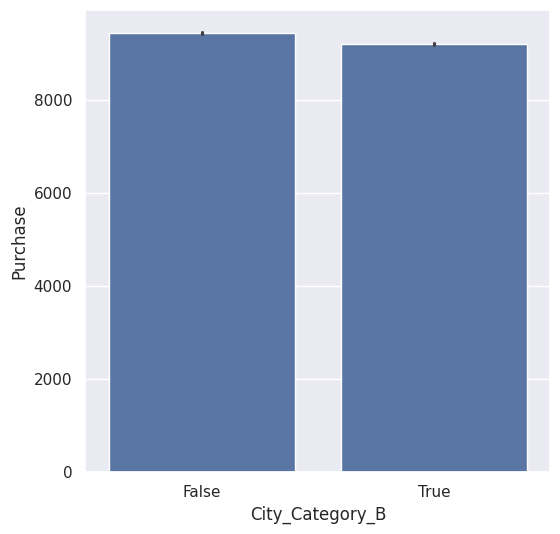

In [315]:
sns.barplot(
    x="City_Category_B",
    y="Purchase",
    data=df
)

<Axes: >

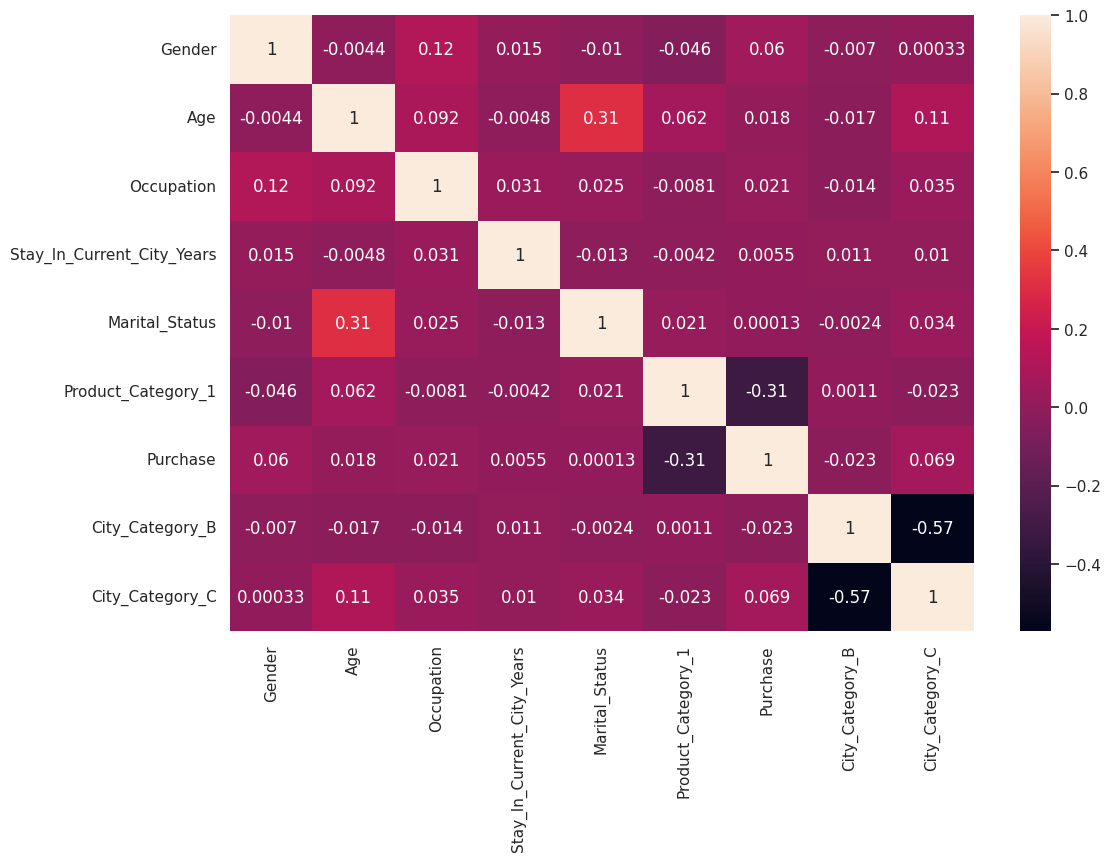

In [316]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True)

In [317]:
df['Gender'].value_counts()

,count
Gender,
1,405380
0,132197


Text(0.5, 1.0, 'Gender Distribution')

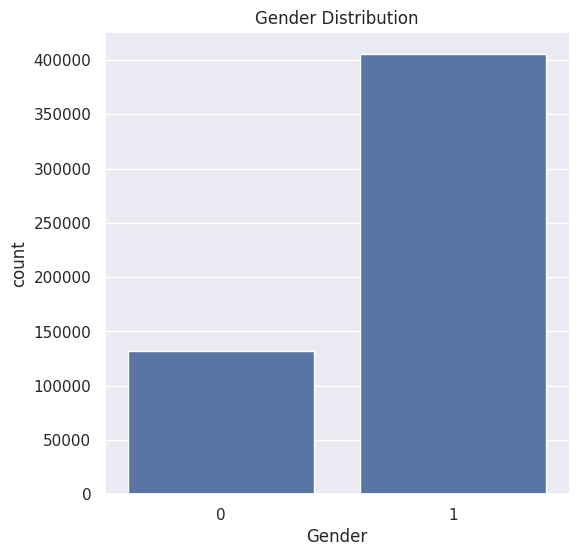

In [318]:
sns.countplot(x='Gender',data=df)
plt.title("Gender Distribution")

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6')])

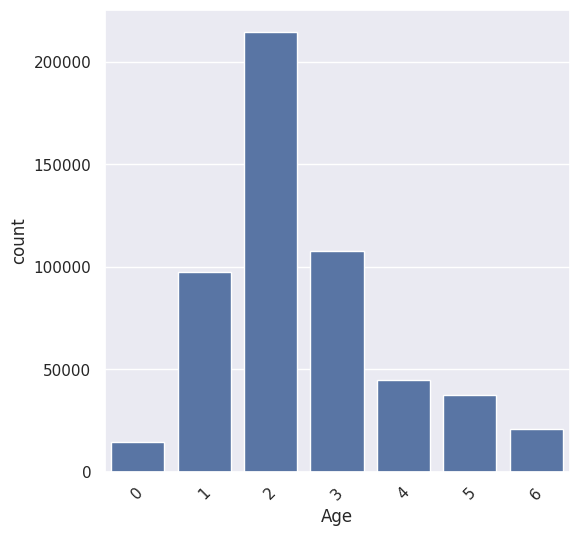

In [319]:
sns.countplot(x='Age',data=df)
plt.xticks(rotation=45)

<Axes: xlabel='Occupation', ylabel='count'>

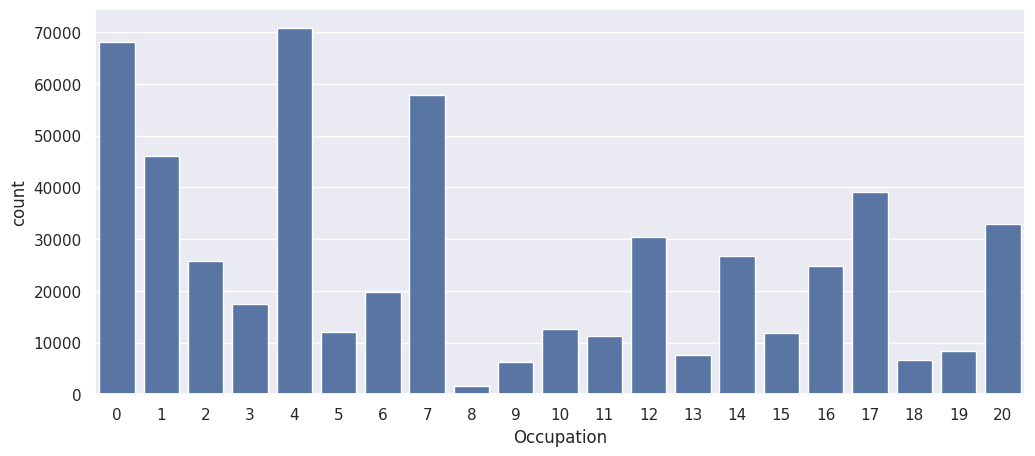

In [320]:
plt.figure(figsize=(12,5))
sns.countplot(x='Occupation',data=df)

In [321]:
print(df.columns.tolist())

['Gender', 'Age', 'Occupation', 'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1', 'Purchase', 'City_Category_B', 'City_Category_C']


In [322]:
import pandas as pd

df = pd.read_csv("BlackFriday.csv")
print(df.columns)

Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1',
       'Product_Category_2', 'Product_Category_3', 'Purchase'],
      dtype='object')


In [323]:
df = pd.get_dummies(df, columns=['City_Category'], drop_first=True)

<Axes: xlabel='Stay_In_Current_City_Years', ylabel='count'>

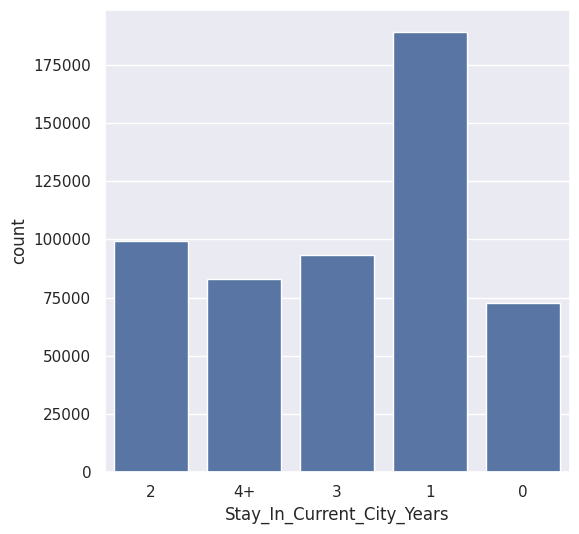

In [324]:
sns.countplot(x='Stay_In_Current_City_Years',data=df)

<Axes: xlabel='Marital_Status', ylabel='count'>

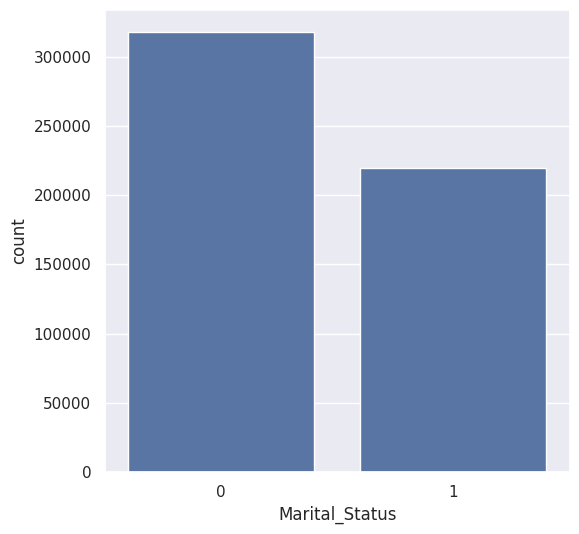

In [325]:
sns.countplot(x='Marital_Status',data=df)

<Axes: xlabel='Product_Category_1', ylabel='count'>

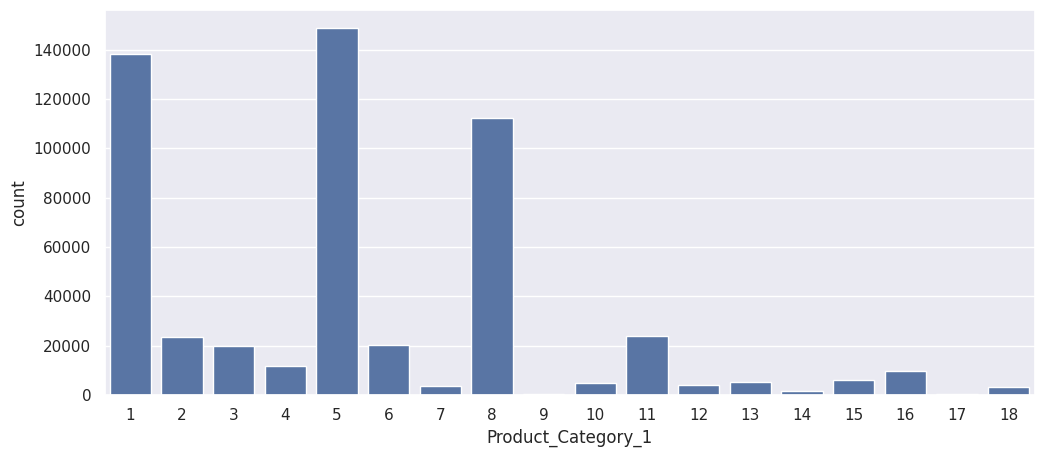

In [326]:
plt.figure(figsize=(12,5))
sns.countplot(x='Product_Category_1',data=df)

<Axes: xlabel='Product_Category_2', ylabel='count'>

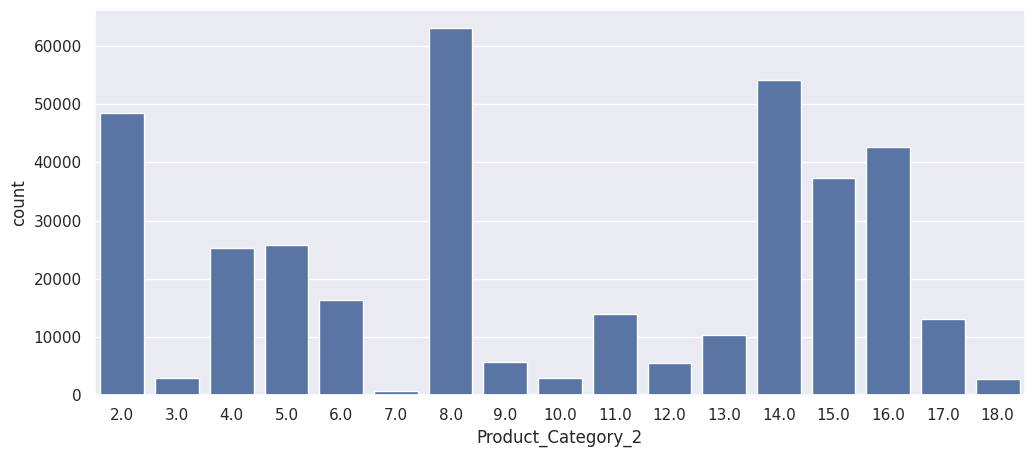

In [327]:
plt.figure(figsize=(12,5))
sns.countplot(x='Product_Category_2',data=df)

<Axes: xlabel='Product_Category_3', ylabel='count'>

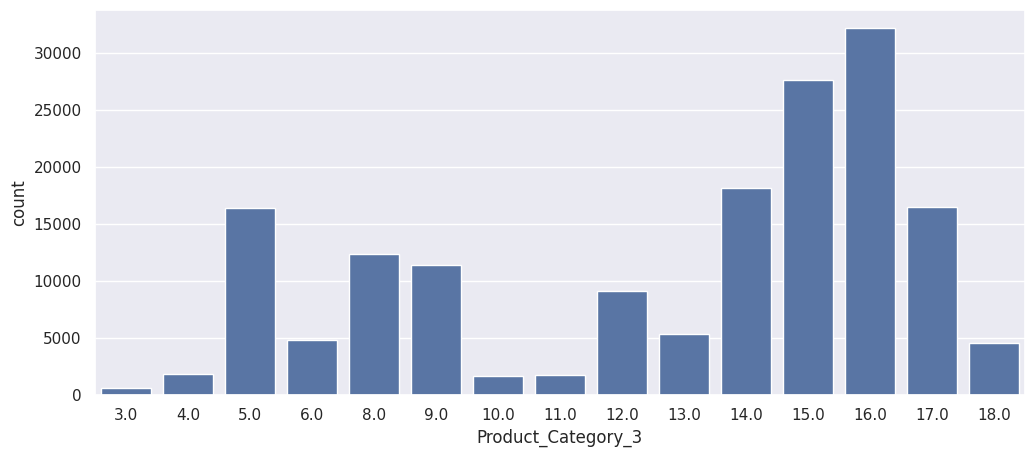

In [328]:
plt.figure(figsize=(12,5))
sns.countplot(x='Product_Category_3',data=df)

<Axes: xlabel='Purchase', ylabel='Count'>

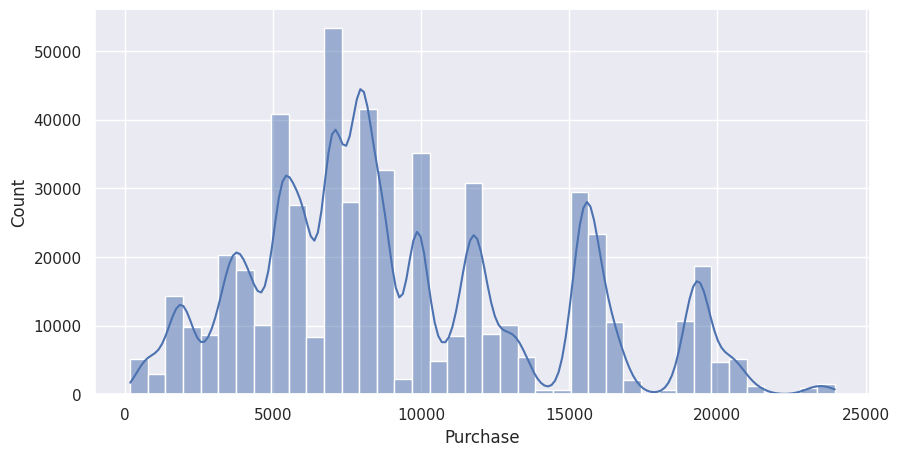

In [329]:
plt.figure(figsize=(10,5))
sns.histplot(df['Purchase'],bins=40,kde=True)

<Axes: xlabel='Purchase'>

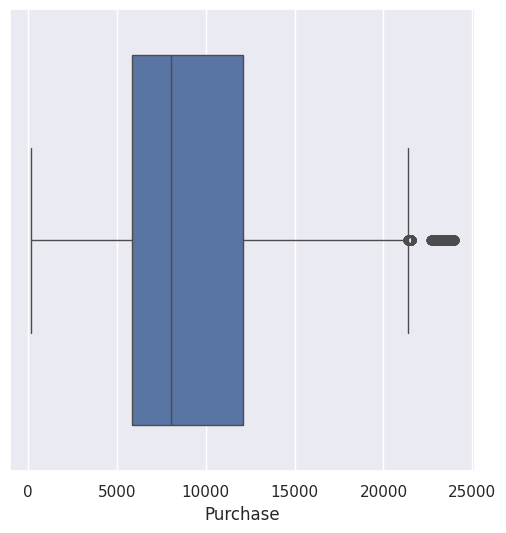

In [330]:
sns.boxplot(x=df['Purchase'])

<Axes: xlabel='Gender', ylabel='Purchase'>

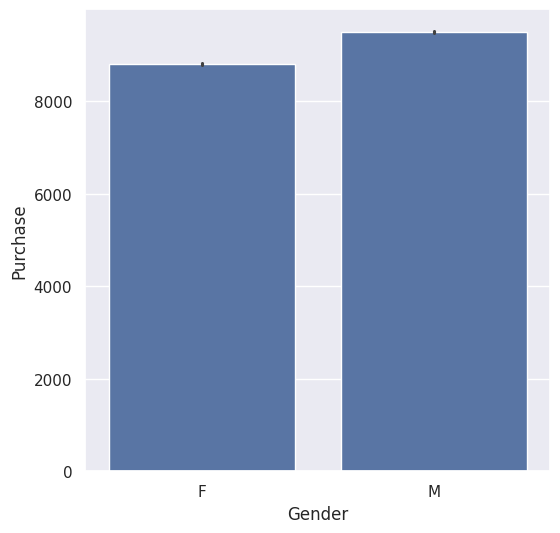

In [331]:
sns.barplot(x='Gender',
            y='Purchase',
            data=df)

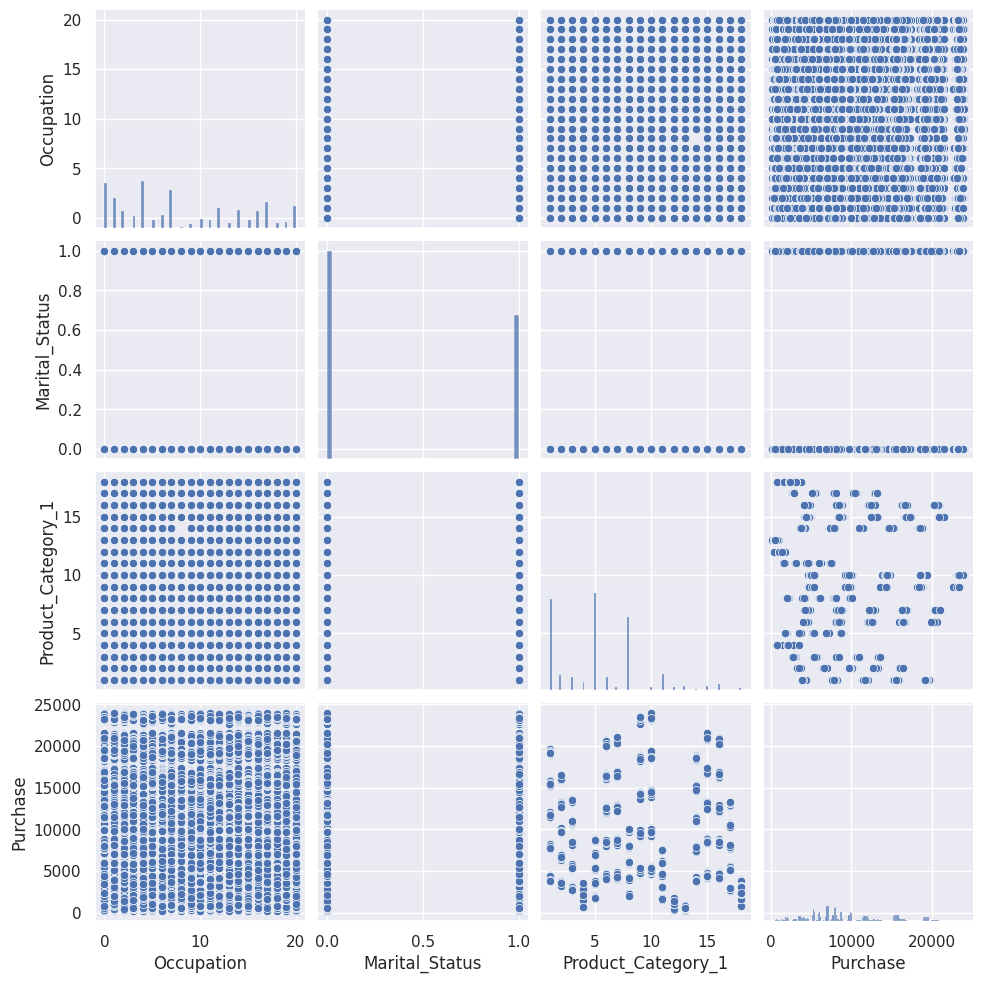

In [332]:
sns.pairplot(df[['Occupation',
                 'Marital_Status',
                 'Product_Category_1',
                 'Purchase']])

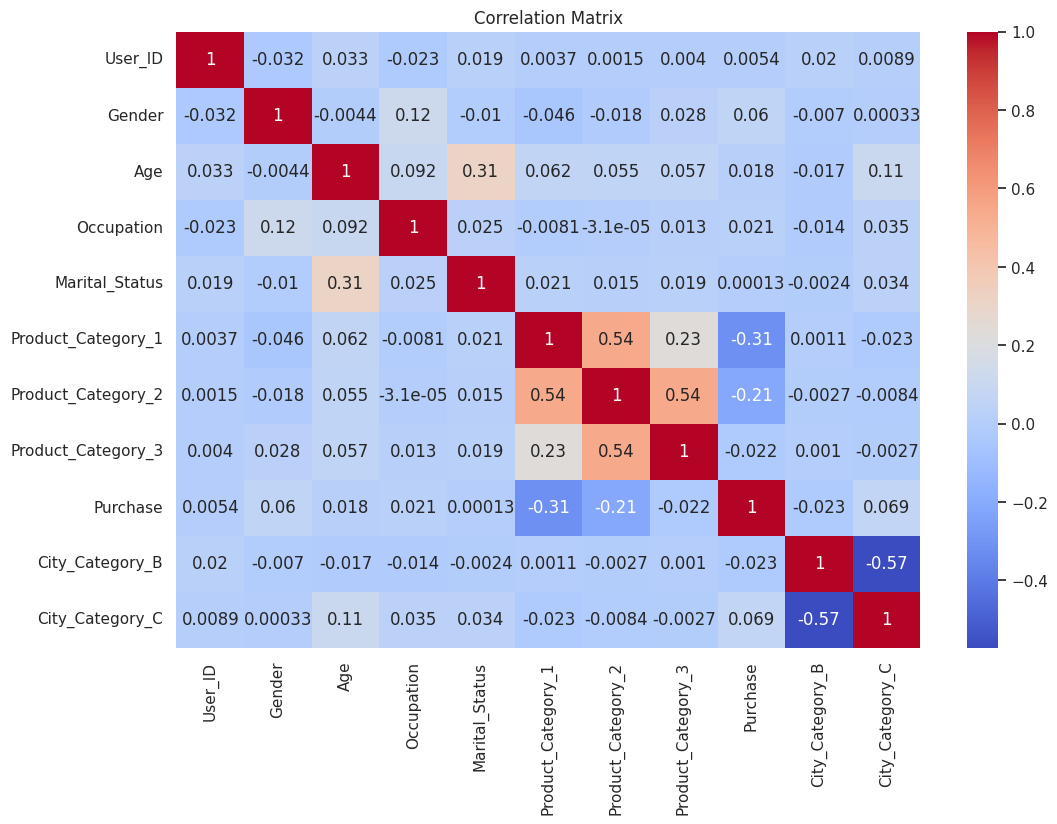

In [333]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df_corr.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

<Axes: >

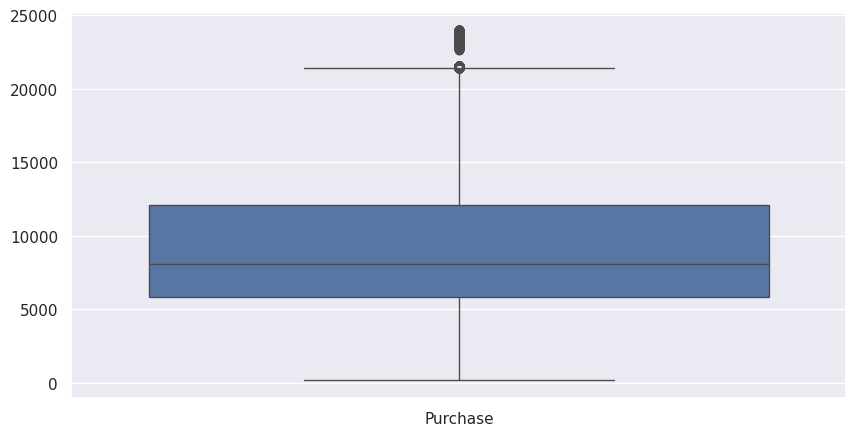

In [334]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df[['Purchase']])

In [335]:
print("Maximum Purchase :",df['Purchase'].max())

print("Minimum Purchase :",df['Purchase'].min())

print("Average Purchase :",df['Purchase'].mean())

print("Median Purchase :",df['Purchase'].median())

Maximum Purchase : 23961
Minimum Purchase : 185
Average Purchase : 9333.859852635065
Median Purchase : 8062.0


<Axes: ylabel='Purchase'>

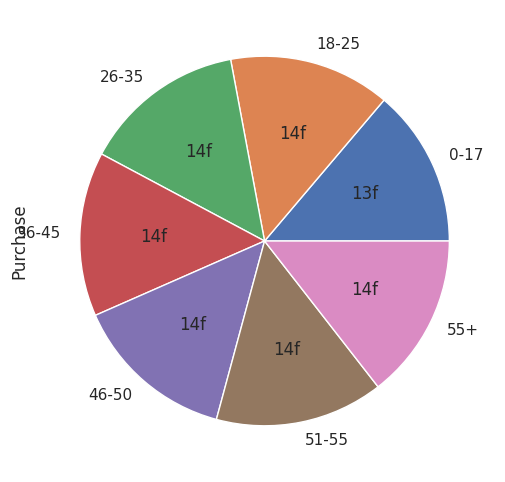

In [336]:
df.groupby('Age')['Purchase'].mean().plot(kind='pie',autopct='%0.if')

<Axes: xlabel='Age', ylabel='count'>

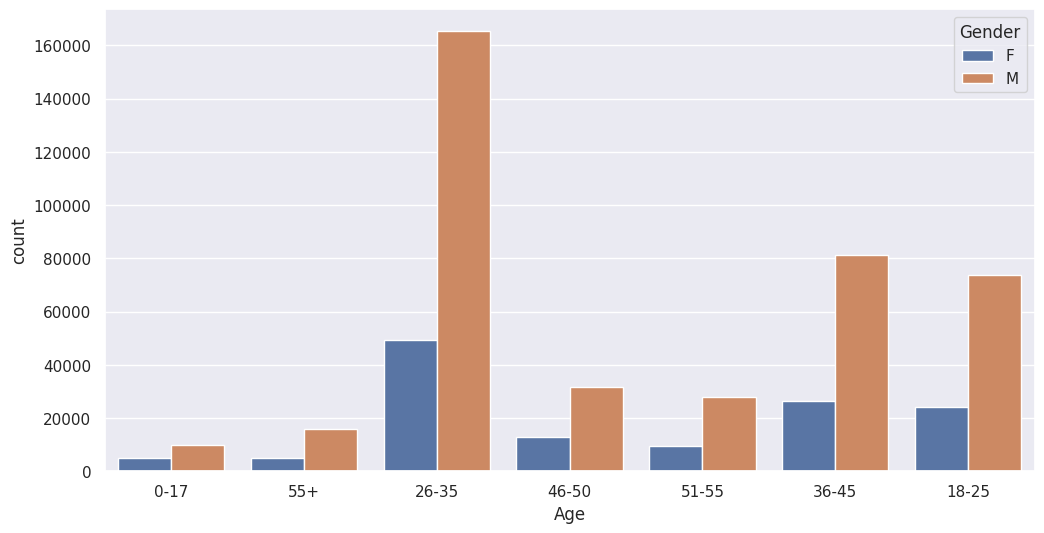

In [337]:
sns.set(rc = {'figure.figsize' : (12,6)})
sns.countplot(x = "Age", hue = 'Gender', data = df)

<Axes: title={'center': 'Purchase Distribution by Age'}, xlabel='Age'>

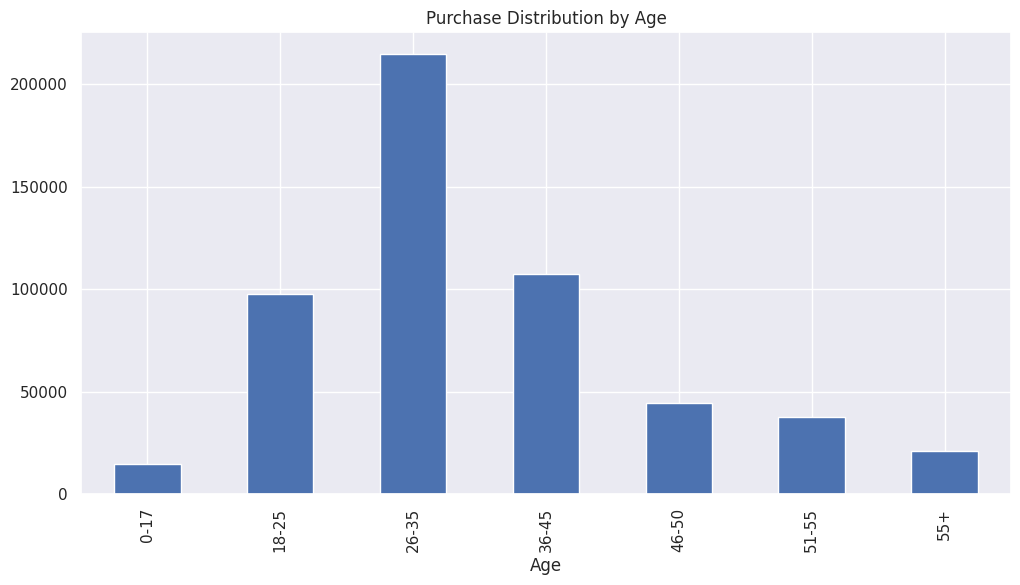

In [338]:
df.groupby('Age').size().plot(kind = 'bar', figsize = (12, 6), title = 'Purchase Distribution by Age')

<Axes: xlabel='Gender', ylabel='count'>

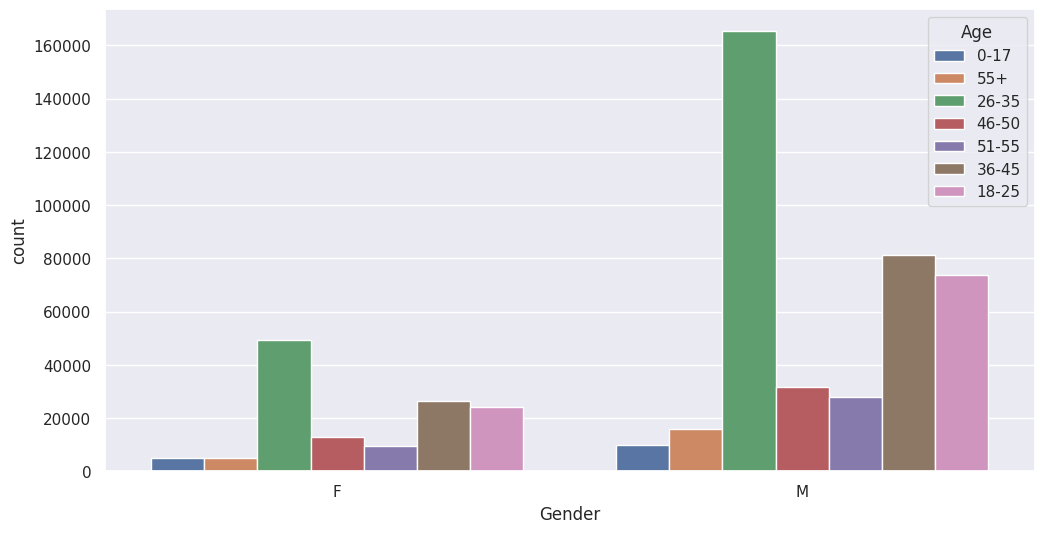

In [339]:
sns.set(rc = {'figure.figsize' : (12,6)})
sns.countplot(x = "Gender", hue = 'Age', data = df)

<Axes: xlabel='Gender', ylabel='count'>

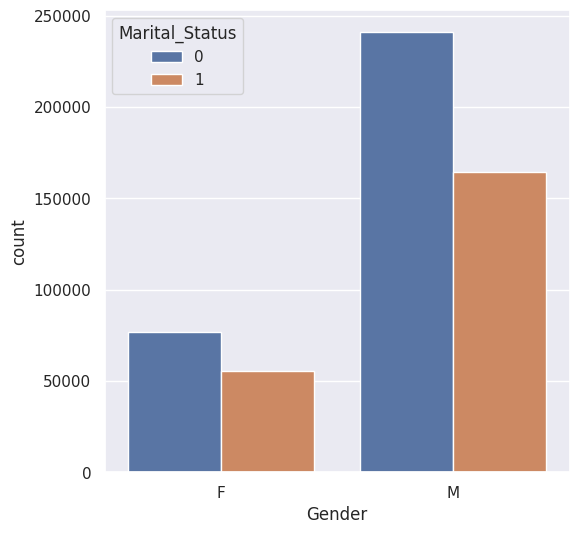

In [340]:
sns.set(rc = {'figure.figsize' : (6,6)})
sns.countplot(x = "Gender", hue = 'Marital_Status', data = df)

<Axes: xlabel='Marital_Status', ylabel='count'>

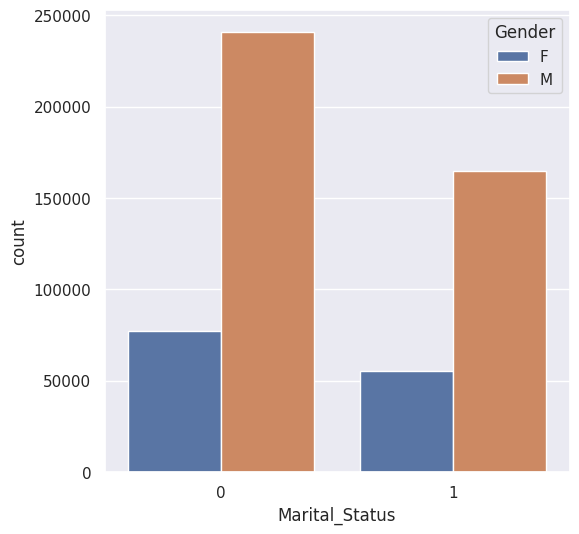

In [341]:
sns.set(rc = {'figure.figsize' : (6,6)})
sns.countplot(x = "Marital_Status", hue = 'Gender', data = df)

In [342]:
X=df.drop("Purchase",axis=1)

y=df["Purchase"]

In [343]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [345]:
df['Product_Category_2'] = df['Product_Category_2'].fillna(0)
df['Product_Category_3'] = df['Product_Category_3'].fillna(0)

In [346]:
df['Product_Category_2'] = df['Product_Category_2'].astype(int)
df['Product_Category_3'] = df['Product_Category_3'].astype(int)

In [347]:
df['Gender'] = df['Gender'].map({'M': 1, 'F': 0})

In [348]:
age_map = {
    '0-17': 0,
    '18-25': 1,
    '26-35': 2,
    '36-45': 3,
    '46-50': 4,
    '51-55': 5,
    '55+': 6
}

df['Age'] = df['Age'].map(age_map)

In [349]:
df['Stay_In_Current_City_Years'] = (
    df['Stay_In_Current_City_Years']
    .replace('4+', 4)
    .astype(int)
)

In [350]:
print(df.dtypes)

User_ID                        int64
Product_ID                    object
Gender                         int64
Age                            int64
Occupation                     int64
Stay_In_Current_City_Years     int64
Marital_Status                 int64
Product_Category_1             int64
Product_Category_2             int64
Product_Category_3             int64
Purchase                       int64
City_Category_B                 bool
City_Category_C                 bool
dtype: object


In [351]:
X = df.drop('Purchase', axis=1)
y = df['Purchase']

In [352]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [353]:
print(X_train.isnull().sum())

User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category_1            0
Product_Category_2            0
Product_Category_3            0
City_Category_B               0
City_Category_C               0
dtype: int64


In [354]:
import pandas as pd

df = pd.read_csv("BlackFriday.csv")

In [355]:
# Drop IDs
df.drop(['User_ID', 'Product_ID'], axis=1, inplace=True)

# Fill missing values
df['Product_Category_2'] = df['Product_Category_2'].fillna(0).astype(int)
df['Product_Category_3'] = df['Product_Category_3'].fillna(0).astype(int)

# Encode Gender
df['Gender'] = df['Gender'].map({'M': 1, 'F': 0})

# Encode Age
age_map = {
    '0-17': 0,
    '18-25': 1,
    '26-35': 2,
    '36-45': 3,
    '46-50': 4,
    '51-55': 5,
    '55+': 6
}
df['Age'] = df['Age'].map(age_map)

# Encode City
df = pd.get_dummies(df, columns=['City_Category'], drop_first=True)

# Convert Stay
df['Stay_In_Current_City_Years'] = (
    df['Stay_In_Current_City_Years']
    .replace('4+', 4)
    .astype(int)
)

In [356]:
print(df.isnull().sum())

Gender                        0
Age                           0
Occupation                    0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category_1            0
Product_Category_2            0
Product_Category_3            0
Purchase                      0
City_Category_B               0
City_Category_C               0
dtype: int64


In [357]:
print(X_train.isnull().sum())

User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category_1            0
Product_Category_2            0
Product_Category_3            0
City_Category_B               0
City_Category_C               0
dtype: int64


In [358]:
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

Series([], dtype: int64)


In [359]:
X = df.drop('Purchase', axis=1)
y = df['Purchase']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [360]:
print(X_train.isnull().sum())

Gender                        0
Age                           0
Occupation                    0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category_1            0
Product_Category_2            0
Product_Category_3            0
City_Category_B               0
City_Category_C               0
dtype: int64


In [361]:
print(df.isnull().sum())

Gender                        0
Age                           0
Occupation                    0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category_1            0
Product_Category_2            0
Product_Category_3            0
Purchase                      0
City_Category_B               0
City_Category_C               0
dtype: int64


In [362]:
X = df.drop('Purchase', axis=1)
y = df['Purchase']

In [363]:
print(X.columns)

Index(['Gender', 'Age', 'Occupation', 'Stay_In_Current_City_Years',
       'Marital_Status', 'Product_Category_1', 'Product_Category_2',
       'Product_Category_3', 'City_Category_B', 'City_Category_C'],
      dtype='object')


In [364]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [365]:
print(X_train.columns)

Index(['Gender', 'Age', 'Occupation', 'Stay_In_Current_City_Years',
       'Marital_Status', 'Product_Category_1', 'Product_Category_2',
       'Product_Category_3', 'City_Category_B', 'City_Category_C'],
      dtype='object')


In [366]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [367]:
from sklearn.ensemble import RandomForestRegressor

rf=RandomForestRegressor()

rf.fit(X_train,y_train)

RandomForestRegressor()

In [368]:
from xgboost import XGBRegressor

xgb=XGBRegressor()

xgb.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [369]:
from sklearn.metrics import *

pred=rf.predict(X_test)

print(r2_score(y_test,pred))

print(mean_absolute_error(y_test,pred))

print(np.sqrt(mean_squared_error(y_test,pred)))

0.6224221584042089
2240.658445491851
3062.1281791870774


In [370]:
import os

os.makedirs("model", exist_ok=True)

In [371]:
import pickle

pickle.dump(rf, open("model/model.pkl", "wb"))

In [372]:
pip install streamlit

In [374]:
!pwd

/content/BlackFriday-Sales-Prediction


In [375]:
!ls -la

total 93352
drwxr-xr-x 4 root root     4096 Jul  8 08:51 .
drwxr-xr-x 1 root root     4096 Jul  8 07:31 ..
-rw-r--r-- 1 root root     1566 Jul  8 08:08 app.py
-rw-r--r-- 1 root root 24418530 Jul  8 08:43 BlackFriday.csv
-rw-r--r-- 1 root root  1284333 Jul  8 07:31 BLaCK_FRiDAY.ipynb
drwxr-xr-x 8 root root     4096 Jul  8 08:29 .git
drwxr-xr-x 2 root root     4096 Jul  8 08:50 model
-rw-r--r-- 1 root root 69856041 Jul  8 08:23 model.pkl
-rw-r--r-- 1 root root     2783 Jul  8 07:31 README.md
-rw-r--r-- 1 root root       62 Jul  8 08:08 requirements.txt


In [376]:
!git clone https://github.com/ompandey0211/BlackFriday-Sales-Prediction.git

Cloning into 'BlackFriday-Sales-Prediction'...
remote: Enumerating objects: 26, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 26 (delta 4), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (26/26), 8.34 MiB | 4.77 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [377]:
%cd BlackFriday-Sales-Prediction

/content/BlackFriday-Sales-Prediction/BlackFriday-Sales-Prediction


In [378]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [379]:
!pwd

/content/BlackFriday-Sales-Prediction/BlackFriday-Sales-Prediction


In [380]:
!ls

 BlackFriday_Project.zip   README.md  'requirements (2).txt'


In [381]:
!zip -r BlackFriday_Project.zip /content/BlackFriday-Sales-Prediction

updating: content/BlackFriday-Sales-Prediction/ (stored 0%)
updating: content/BlackFriday-Sales-Prediction/BLaCK_FRiDAY.ipynb (deflated 39%)
updating: content/BlackFriday-Sales-Prediction/README.md (deflated 56%)
updating: content/BlackFriday-Sales-Prediction/.git/ (stored 0%)
updating: content/BlackFriday-Sales-Prediction/.git/logs/ (stored 0%)
updating: content/BlackFriday-Sales-Prediction/.git/logs/refs/ (stored 0%)
updating: content/BlackFriday-Sales-Prediction/.git/logs/refs/remotes/ (stored 0%)
updating: content/BlackFriday-Sales-Prediction/.git/logs/refs/remotes/origin/ (stored 0%)
updating: content/BlackFriday-Sales-Prediction/.git/logs/refs/remotes/origin/HEAD (deflated 27%)
updating: content/BlackFriday-Sales-Prediction/.git/logs/refs/heads/ (stored 0%)
updating: content/BlackFriday-Sales-Prediction/.git/logs/refs/heads/main (deflated 27%)
updating: content/BlackFriday-Sales-Prediction/.git/logs/HEAD (deflated 27%)
updating: content/BlackFriday-Sales-Prediction/.git/packed-re

In [382]:
!find /content -type f

/content/.config/gce
/content/.config/logs/2026.06.04/13.32.02.654775.log
/content/.config/logs/2026.06.04/13.31.42.499627.log
/content/.config/logs/2026.06.04/13.32.39.344962.log
/content/.config/logs/2026.06.04/13.32.18.735754.log
/content/.config/logs/2026.06.04/13.32.38.346437.log
/content/.config/logs/2026.06.04/13.32.21.210570.log
/content/.config/.last_opt_in_prompt.yaml
/content/.config/configurations/config_default
/content/.config/.last_survey_prompt.yaml
/content/.config/active_config
/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/default_configs.db
/content/.config/.last_update_check.json
/content/.config/config_sentinel
/content/BlackFriday (3).csv
/content/model/model.pkl
/content/BlackFriday (2).csv
/content/BlackFriday.csv
/content/BlackFriday-Sales-Prediction/model.pkl
/content/BlackFriday-Sales-Prediction/BLaCK_FRiDAY.ipynb
/content/BlackFriday-Sales-Prediction/requirements.txt
/content/BlackFriday-Sales-Prediction/mod

In [383]:
!ls -R /content/model

/content/model:
model.pkl


In [384]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

# Load model
model = joblib.load("model/model.pkl")

st.title("Black Friday Sales Prediction")

st.write("Enter customer details to predict purchase amount")

# Inputs
gender = st.selectbox("Gender", ["M", "F"])
age = st.selectbox(
    "Age",
    ["0-17", "18-25", "26-35", "36-45", "46-50", "51-55", "55+"]
)

occupation = st.number_input("Occupation", min_value=0, max_value=20)
city_category = st.selectbox("City Category", ["A", "B", "C"])
stay_years = st.selectbox(
    "Stay In Current City Years",
    ["0", "1", "2", "3", "4+"]
)

marital_status = st.selectbox(
    "Marital Status",
    [0, 1]
)

product_category_1 = st.number_input(
    "Product Category 1",
    min_value=1
)

product_category_2 = st.number_input(
    "Product Category 2",
    min_value=0
)

product_category_3 = st.number_input(
    "Product Category 3",
    min_value=0
)


if st.button("Predict Purchase"):

    input_data = pd.DataFrame({
        "Gender": [gender],
        "Age": [age],
        "Occupation": [occupation],
        "Stay_In_Current_City_Years": [stay_years],
        "Marital_Status": [marital_status],
        "Product_Category_1": [product_category_1],
        "Product_Category_2": [product_category_2],
        "Product_Category_3": [product_category_3],
        "City_Category_B": [1 if city_category == "B" else 0],
        "City_Category_C": [1 if city_category == "C" else 0]
    })

    prediction = model.predict(input_data)

    st.success(f"Predicted Purchase Amount: ₹{prediction[0]:.2f}")

Writing app.py


In [385]:
!zip -r model.zip /content/model/model.pkl

  adding: content/model/model.pkl (deflated 79%)


In [386]:
!ls -lh model.zip

-rw-r--r-- 1 root root 285M Jul  8 08:54 model.zip


In [387]:
import joblib

model = joblib.load('/content/model/model.pkl')

print(type(model))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [388]:
print("Number of trees:", len(model.estimators_))
print("Model size:", model.__sizeof__() / (1024**2), "MB")

Number of trees: 100
Model size: 1.52587890625e-05 MB


In [389]:
RandomForestRegressor(
    n_estimators=1000,
    max_depth=None
)

RandomForestRegressor(n_estimators=1000)

In [390]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, n_jobs=-1, random_state=42)

In [391]:
import joblib

joblib.dump(model, "model.pkl", compress=3)

['model.pkl']

In [392]:
import os

size = os.path.getsize("model.pkl") / (1024**2)
print(f"{size:.2f} MB")

148.55 MB


In [393]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, min_samples_leaf=5, min_samples_split=10,
                      n_jobs=-1, random_state=42)

In [394]:
import joblib

joblib.dump(rf_model, "model.pkl", compress=3)


['model.pkl']

In [395]:
import os

print(os.path.getsize("model.pkl")/(1024**2), "MB")

71.25389671325684 MB


In [396]:
import joblib

joblib.dump(
    rf_model,
    "model.pkl",
    compress=9
)

['model.pkl']

In [397]:
import os

print(os.path.getsize("model.pkl")/(1024**2), "MB")

66.61991214752197 MB


In [398]:
!ls -la /content/BlackFriday-Sales-Prediction

total 93356
drwxr-xr-x 5 root root     4096 Jul  8 08:52 .
drwxr-xr-x 1 root root     4096 Jul  8 07:31 ..
-rw-r--r-- 1 root root     1566 Jul  8 08:08 app.py
-rw-r--r-- 1 root root 24418530 Jul  8 08:43 BlackFriday.csv
-rw-r--r-- 1 root root  1284333 Jul  8 07:31 BLaCK_FRiDAY.ipynb
drwxr-xr-x 3 root root     4096 Jul  8 08:56 BlackFriday-Sales-Prediction
drwxr-xr-x 8 root root     4096 Jul  8 08:29 .git
drwxr-xr-x 2 root root     4096 Jul  8 08:50 model
-rw-r--r-- 1 root root 69856041 Jul  8 08:23 model.pkl
-rw-r--r-- 1 root root     2783 Jul  8 07:31 README.md
-rw-r--r-- 1 root root       62 Jul  8 08:08 requirements.txt


In [399]:
!rm model.zip

In [401]:
!rm BlackFriday_Project.zip

In [400]:
!ls -lh

total 499M
-rw-r--r-- 1 root root 1.6K Jul  8 08:53  app.py
-rw-r--r-- 1 root root 432M Jul  8 08:53  BlackFriday_Project.zip
-rw-r--r-- 1 root root  67M Jul  8 08:59  model.pkl
-rw-r--r-- 1 root root 2.8K Jul  8 08:52  README.md
-rw-r--r-- 1 root root   62 Jul  8 08:52 'requirements (2).txt'


In [402]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add/rm <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	deleted:    BlackFriday_Project.zip

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	app.py
	model.pkl

no changes added to commit (use "git add" and/or "git commit -a")


In [403]:
!git add .
!git commit -m "Added optimized model and Streamlit deployment files"
!git push origin main

Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@f2eee6ce6bc1.(none)')
fatal: could not read Username for 'https://github.com': No such device or address


In [404]:
model = joblib.load("model.pkl")

In [405]:
joblib.load("model.pkl")

RandomForestRegressor(max_depth=20, min_samples_leaf=5, min_samples_split=10,
                      n_jobs=-1, random_state=42)